In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [ ]:
missing_values = df.isnull().sum()

print(missing_values)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [ ]:
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])
df = df.drop(columns=["deck"])
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [ ]:
print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 116


In [ ]:
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (891, 14)


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


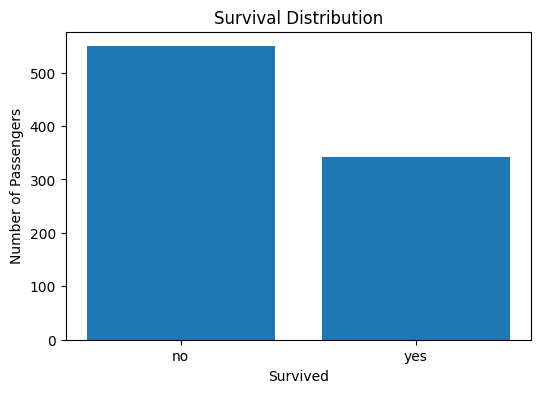

In [ ]:
survival_counts = df["alive"].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(survival_counts.index, survival_counts.values)
plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.show()

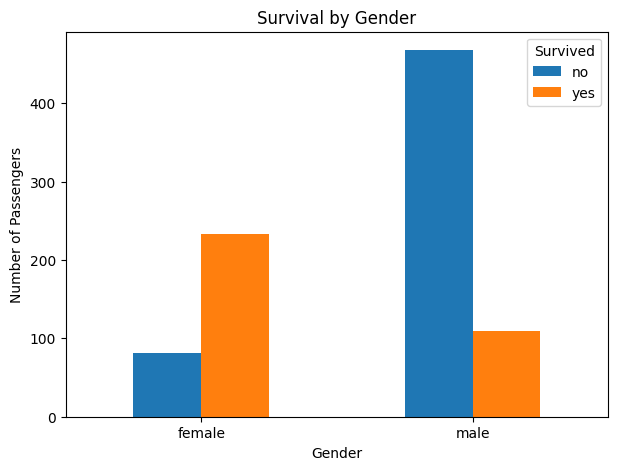

In [ ]:
survival_by_sex = df.groupby(["sex", "alive"]).size().unstack()
survival_by_sex.plot(kind="bar", figsize=(7, 5))
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.legend(title="Survived")
plt.show()

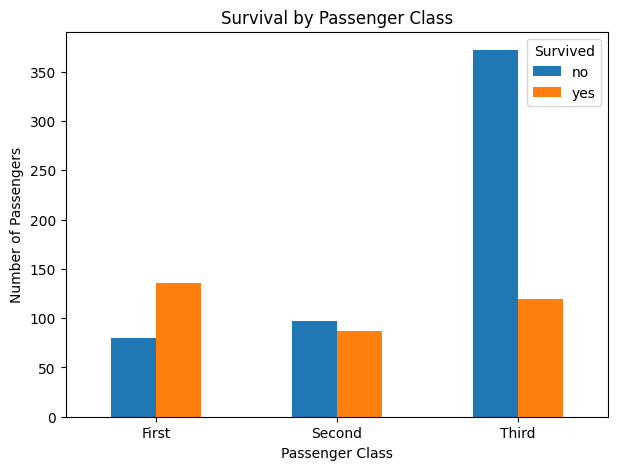

In [ ]:
survival_by_class = df.groupby(["class", "alive"]).size().unstack()
survival_by_class.plot(kind="bar", figsize=(7, 5))
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.legend(title="Survived")
plt.show()

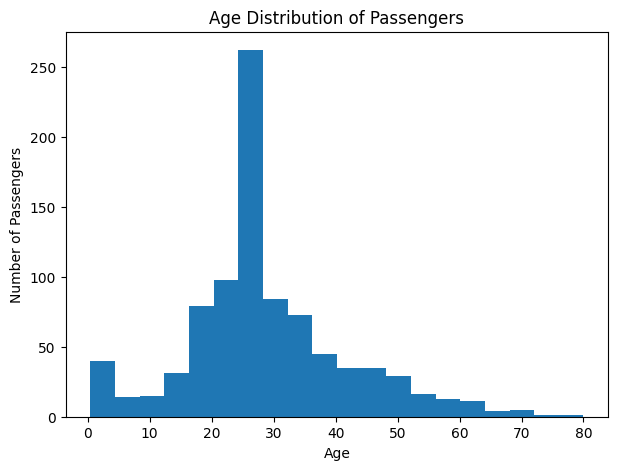

In [ ]:
plt.figure(figsize=(7, 5))
plt.hist(df["age"], bins=20)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

In [ ]:
print("Total passengers:", len(df))
print("\nSurvival rate:")
print(df["alive"].value_counts(normalize=True) * 100)
print("\nSurvival by gender:")
print(df.groupby("sex")["survived"].mean() * 100)
print("\nSurvival by passenger class:")
print(df.groupby("class")["survived"].mean() * 100)
print("\nAverage age:", df["age"].mean())
print("Average fare:", df["fare"].mean())

Total passengers: 891

Survival rate:
alive
no     61.616162
yes    38.383838
Name: proportion, dtype: float64

Survival by gender:
sex
female    74.203822
male      18.890815
Name: survived, dtype: float64

Survival by passenger class:
class
First     62.962963
Second    47.282609
Third     24.236253
Name: survived, dtype: float64

Average age: 29.36158249158249
Average fare: 32.204207968574636


In [ ]:
df.to_csv("cleaned_titanic_dataset.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
from google.colab import files
files.download("cleaned_titanic_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
### Key Insights
- The dataset contains 891 passengers and 14 columns after cleaning.
- Missing values in the age column were replaced using the median.
- Missing categorical values in embarked and embark_town were replaced using the mode.
- The deck column was removed because it contained a large number of missing values.
- The analysis shows differences in survival rates across genders and passenger classes.
- The age distribution shows that passengers had a wide range of ages.